# Canopy Height API Demo

In [1]:
from shelterbelts.apis.canopy_height import canopy_height

## Default Parameters
The default location is a roughly 1km x 1km region near Milgadara, NSW, Australia. 
The first download can take a few minutes as tiles need to be fetched from AWS (~200MB per tile).

In [2]:
%%time
ds = canopy_height()

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./Test_canopy_height.tif
Saved: ./Test_canopy_height.png
CPU times: user 11.3 s, sys: 839 ms, total: 12.1 s
Wall time: 22.9 s


## Visualising the Results
You can view the results inside the notebook, or in preview as a PNG or TIF, or properly geolocated in QGIS.

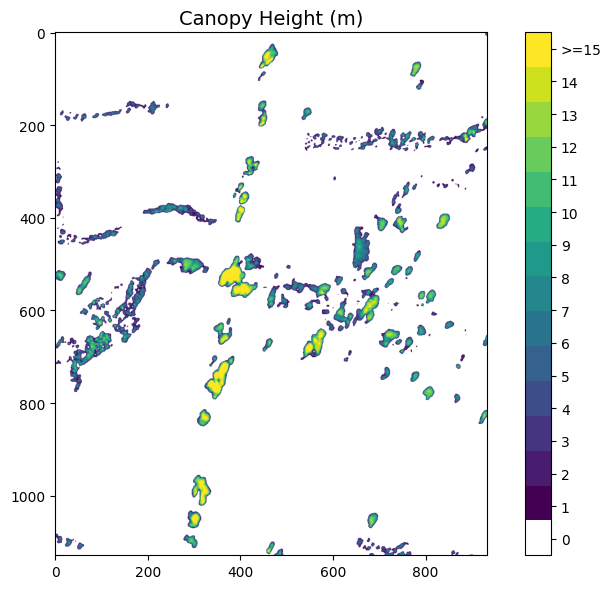

In [3]:
from shelterbelts.apis.canopy_height import visualise_canopy_height

visualise_canopy_height(ds)

## Changing Buffer Size
You can adjust the buffer parameter to change the size of the downloaded region. 
The buffer is in degrees (~1 degree ≈ 100 km depending on the latitude) in each direction from the centre point.

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./Test_canopy_height.tif
Saved: ./Test_canopy_height.png


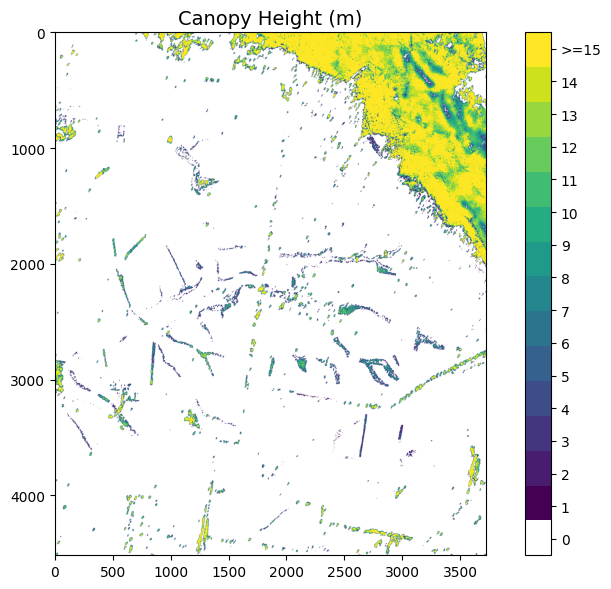

In [4]:
ds_larger = canopy_height(buffer=0.02)
visualise_canopy_height(ds_larger)

## Changing Location
Use the lat and lon arguments to download data for a different location.

Working on 0/1: 3112302113
Merging 1 tiles
Saved: ./Test_canopy_height.tif
Saved: ./Test_canopy_height.png


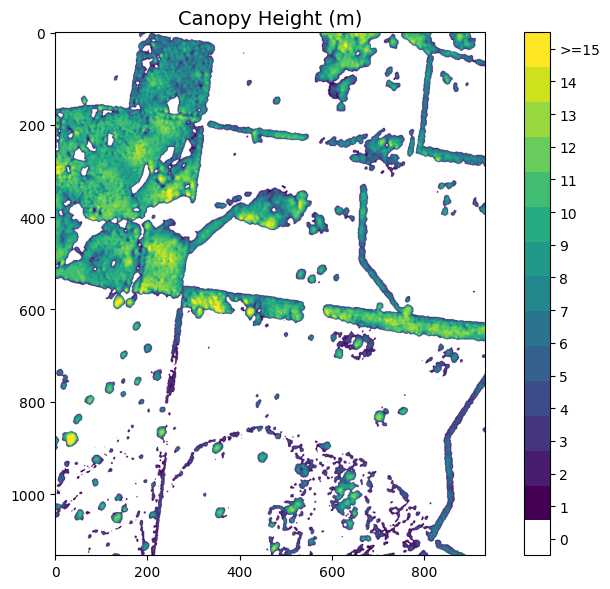

In [5]:
ds_laverstock = canopy_height(lat=-34.68, lon=148.96)
visualise_canopy_height(ds_laverstock)

## Changing Output Directory
Specify a custom output directory for the saved files.

In [6]:
import os
outdir = "outdir"
os.makedirs(outdir, exist_ok=True)
ds = canopy_height(outdir=outdir)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: outdir/Test_canopy_height.tif
Saved: outdir/Test_canopy_height.png


## Changing Filename Prefix
Choose a stub to be used as the prefix for output filenames.

In [7]:
ds = canopy_height(stub="DEMO")

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./DEMO_canopy_height.tif
Saved: ./DEMO_canopy_height.png


## Changing Temporary Directory
You can specify a custom temporary directory to cache these tiles downloaded from AWS for reuse. Otherwise they just get cached in the working directory.

In [8]:
tmpdir = "tmpdir"
os.makedirs(tmpdir, exist_ok=True)
ds = canopy_height(tmpdir=tmpdir)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./Test_canopy_height.tif
Saved: ./Test_canopy_height.png


## Disabling GeoTIFF Output
Set `save_tif=False` to skip saving the GeoTIFF file. Useful for when running within a larger pipeline.

In [9]:
ds = canopy_height(save_tif=False)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./Test_canopy_height.png


## Disabling Visualisation Plot
Set `plot=False` to skip generating and saving the PNG visualisation. 
This can be used in combination with `save_tif=False` to avoid any outputs.

In [10]:
ds = canopy_height(plot=False)

Working on 0/1: 3112302110
Merging 1 tiles
Saved: ./Test_canopy_height.tif


## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [11]:
!python -m shelterbelts.apis.canopy_height --help

usage: canopy_height.py [-h] [--lat LAT] [--lon LON] [--buffer BUFFER]
                        [--outdir OUTDIR] [--stub STUB] [--tmpdir TMPDIR]
                        [--no-save-tif] [--no-plot]

options:
  -h, --help       show this help message and exit
  --lat LAT        Latitude in EPSG:4326 (default: -34.389)
  --lon LON        Longitude in EPSG:4326 (default: 148.469)
  --buffer BUFFER  Buffer in each direction in degrees (default: 0.005)
  --outdir OUTDIR  Output directory for saving results (default: current
                   directory)
  --stub STUB      Prefix for output filenames (default: Test)
  --tmpdir TMPDIR  Directory to cache downloaded tiles (default: current
                   directory)
  --no-save-tif    Disable saving GeoTIFF (default: enabled)
  --no-plot        Disable PNG visualisation (default: enabled)


In [14]:
!python -m shelterbelts.apis.canopy_height --lat -34.68 --lon 148.96 --buffer 0.01 --stub command_line

Working on 0/1: 3112302113
Merging 1 tiles
Saved: ./command_line_canopy_height.tif
Saved: ./command_line_canopy_height.png


### Cleanup
Remove the output files created by this notebook

In [15]:
# !rm *.tif
# !rm *.png
# !rm *.geojson